### Ridge Regression

Ridge Regression is a linear regression variant that adds a penalty term (α × sum of squared coefficients) to the loss function. This penalty shrinks coefficients toward zero, reducing overfitting. Unlike standard regression which minimizes just the error, Ridge balances between fitting the data AND keeping coefficients small. The α parameter controls this trade-off: larger α = more shrinkage, simpler model, higher bias but lower variance.

📊 RIDGE REGRESSION:
You have 100 features. Ridge says:
"Okay, use ALL of them, but keep each one's influence small"

🎯 LASSO REGRESSION:
You have 100 features. Lasso says:
"Let me pick the MOST important 10 features and ignore the rest"

Which is better?
→ Ridge: When you believe ALL features have SOME effect
→ Lasso: When you believe ONLY SOME features matter

### Overfitting Prevention- How they work

Bias-Variance Tradeoff:

High Variance (Overfitting) ←→ High Bias (Underfitting)

Ridge/Lasso shift you from overfitting → better generalization

Example with α values:
α = 0      → High variance (overfit) ❌
α = medium → Sweet spot (best test performance) ✅
α = huge   → High bias (underfit) ❌

In [5]:
print("""STANDARD LINEAR REGRESSION:
Loss = Σ(yᵢ - ŷᵢ)²
No penalty → coefficients can grow huge → OVERFITTING

RIDGE (L2):
Loss = Σ(yᵢ - ŷᵢ)² + α·Σ(wⱼ²)
                     ↑
              Penalizes SQUARED coefficients
              Coeffs shrink → approach zero but never reach it

LASSO (L1):
Loss = Σ(yᵢ - ŷᵢ)² + α·Σ|wⱼ|
                     ↑
              Penalizes ABSOLUTE coefficients
              Coeffs can become EXACTLY zero → FEATURE SELECTION""")

STANDARD LINEAR REGRESSION:
Loss = Σ(yᵢ - ŷᵢ)²
No penalty → coefficients can grow huge → OVERFITTING

RIDGE (L2):
Loss = Σ(yᵢ - ŷᵢ)² + α·Σ(wⱼ²)
                     ↑
              Penalizes SQUARED coefficients
              Coeffs shrink → approach zero but never reach it

LASSO (L1):
Loss = Σ(yᵢ - ŷᵢ)² + α·Σ|wⱼ|
                     ↑
              Penalizes ABSOLUTE coefficients
              Coeffs can become EXACTLY zero → FEATURE SELECTION


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge,Lasso

# Create sample data
np.random.seed(42)
X = np.random.randn(50,1)
y = 2*X.ravel() + np.random.randn(50)*0.1

print(X)
print(y)

[[ 0.49671415]
 [-0.1382643 ]
 [ 0.64768854]
 [ 1.52302986]
 [-0.23415337]
 [-0.23413696]
 [ 1.57921282]
 [ 0.76743473]
 [-0.46947439]
 [ 0.54256004]
 [-0.46341769]
 [-0.46572975]
 [ 0.24196227]
 [-1.91328024]
 [-1.72491783]
 [-0.56228753]
 [-1.01283112]
 [ 0.31424733]
 [-0.90802408]
 [-1.4123037 ]
 [ 1.46564877]
 [-0.2257763 ]
 [ 0.0675282 ]
 [-1.42474819]
 [-0.54438272]
 [ 0.11092259]
 [-1.15099358]
 [ 0.37569802]
 [-0.60063869]
 [-0.29169375]
 [-0.60170661]
 [ 1.85227818]
 [-0.01349722]
 [-1.05771093]
 [ 0.82254491]
 [-1.22084365]
 [ 0.2088636 ]
 [-1.95967012]
 [-1.32818605]
 [ 0.19686124]
 [ 0.73846658]
 [ 0.17136828]
 [-0.11564828]
 [-0.3011037 ]
 [-1.47852199]
 [-0.71984421]
 [-0.46063877]
 [ 1.05712223]
 [ 0.34361829]
 [-1.76304016]]
[ 1.0258367  -0.31503683  1.22768488  3.10722734 -0.3652068  -0.3751459
  3.07450388  1.50394822 -0.90582243  1.1826746  -0.97475281 -0.9500254
  0.37329105 -3.94618115 -3.36858308 -0.98895106 -2.03286325  0.72884795
 -1.77988455 -2.88911938  2.9674

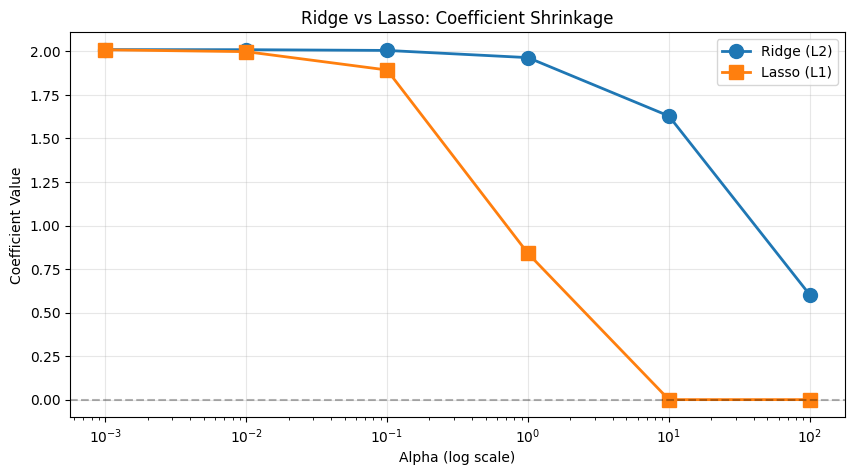

Coefficients comparison:
Alpha	Ridge	Lasso
------------------------------
0.001	2.0103	2.0091
0.01	2.0098	1.9986
0.1	2.0056	1.8933
1	1.9643	0.8398
10	1.6290	0.0000
100	0.6017	0.0000


In [ ]:
# Test difference alphas
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    ridge_coefs.append(ridge.coef_[0])
    
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    lasso_coefs.append(lasso.coef_[0])

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_coefs, 'o-', label='Ridge (L2)', linewidth=2, markersize=10)
plt.plot(alphas, lasso_coefs, 's-', label='Lasso (L1)', linewidth=2, markersize=10)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Ridge vs Lasso: Coefficient Shrinkage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Coefficients comparison:")
print("Alpha\tRidge\tLasso")
print("-"*30)
for a, r, l in zip(alphas, ridge_coefs, lasso_coefs):
    print(f"{a}\t{r:.4f}\t{l:.4f}")



"Ridge adds penalty to shrink coefficients but never zero (L2 penalty), while Lasso can make them exactly zero (L1 penalty). Both prevent overfitting by reducing model complexity."

BONUS INSIGHT: Ridge is mathematically more stable (always has a unique solution) because adding αI to XᵀX makes it invertible. Lasso can be unstable when features are correlated!

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset (using Diabetes since Boston is deprecated)
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  

print(data)

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10)), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59

LINEAR REGRESSION RESULTS (Yesterday's Model)
MSE: 2900.1936
R² Score: 0.4526

Coefficients:
  age: 1.7538
  sex: -11.5118
  bmi: 25.6071
  bp: 16.8289
  s1: -44.4489
  s2: 24.6410
  s3: 7.6770
  s4: 13.1388
  s5: 35.1612
  s6: 2.3514

RIDGE REGRESSION RESULTS

α = 0.01
  MSE: 2900.0751
  R² Score: 0.4526
  Coefficients: ['1.7545', '-11.5111', '25.6089', '16.8277', '-44.3215', '24.5420', '7.6209', '13.1210', '35.1120', '2.3526']

α = 0.1
  MSE: 2899.0546
  R² Score: 0.4528
  Coefficients: ['1.7605', '-11.5049', '25.6247', '16.8178', '-43.2097', '23.6777', '7.1309', '12.9653', '34.6826', '2.3640']

α = 1
  MSE: 2892.0146
  R² Score: 0.4541
  Coefficients: ['1.8073', '-11.4482', '25.7327', '16.7343', '-34.6720', '17.0531', '3.3699', '11.7643', '31.3784', '2.4581']

α = 10
  MSE: 2875.7787
  R² Score: 0.4572
  Coefficients: ['1.9313', '-11.0282', '25.6056', '16.3042', '-12.9342', '0.5382', '-6.1251', '8.5695', '22.7493', '2.9181']


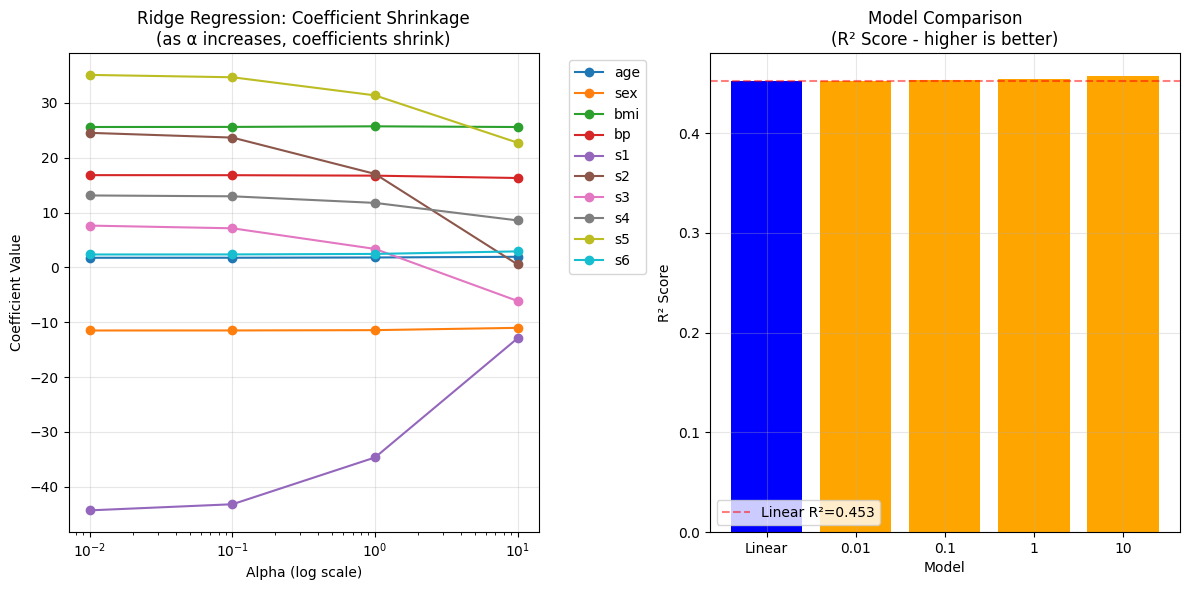


COMPARISON SUMMARY
Linear Regression R²: 0.4526
Best Ridge (α=10) R²: 0.4572

Improvement: 0.0046
 Ridge Regression performed BETTER than Linear Regression


In [ ]:


# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Metrics for LR
lr_mse = mean_squared_error(y_test,y_pred_lr)
lr_r2 = r2_score(y_test,y_pred_lr)

print("="*60)
print("LINEAR REGRESSION RESULTS (Yesterday's Model)")
print("="*60)
print(f"MSE: {lr_mse:.4f}")
print(f"R² Score: {lr_r2:.4f}")
print("\nCoefficients:")
for name, coef in zip(feature_names, lr.coef_):
    print(f"  {name}: {coef:.4f}")


# 2. Ridge Regression with different alpha values
alphas = [0.01, 0.1, 1, 10]
ridge_results = {}

print("\n" + "="*60)
print("RIDGE REGRESSION RESULTS")
print("="*60)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    ridge_results[alpha] = {
        'model': ridge,
        'mse': mse,
        'r2': r2,
        'coef': ridge.coef_
    }

    print(f"\nα = {alpha}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Coefficients: {[f'{c:.4f}' for c in ridge.coef_]}")


# 3. Visualization - Coefficients Shrinkage
plt.figure(figsize=(12, 6))

# Plot coefficients vs alpha
plt.subplot(1, 2, 1)
for i, feature in enumerate(feature_names):
    coefs = [ridge_results[alpha]['coef'][i] for alpha in alphas]
    plt.plot(alphas, coefs, marker='o', label=feature)

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Shrinkage\n(as α increases, coefficients shrink)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Compare R² scores
plt.subplot(1, 2, 2)
alphas_labels = [str(a) for a in alphas]
r2_scores = [ridge_results[alpha]['r2'] for alpha in alphas]

plt.bar(['Linear'] + alphas_labels, [lr_r2] + r2_scores, color=['blue'] + ['orange']*4)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison\n(R² Score - higher is better)')
plt.axhline(y=lr_r2, color='red', linestyle='--', alpha=0.5, label=f'Linear R²={lr_r2:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Best Ridge model comparison to Linear
best_alpha = min(alphas, key=lambda a: ridge_results[a]['mse'])
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"Linear Regression R²: {lr_r2:.4f}")
print(f"Best Ridge (α={best_alpha}) R²: {ridge_results[best_alpha]['r2']:.4f}")
print(f"\nImprovement: {(ridge_results[best_alpha]['r2'] - lr_r2):.4f}")

if ridge_results[best_alpha]['r2'] > lr_r2:
    print(" Ridge Regression performed BETTER than Linear Regression")
else:
    print(" Ridge Regression performed WORSE than Linear Regression")
    print("   (This can happen if data doesn't have multicollinearity)")



In [6]:
print("""USE RIDGE when:
✅ All features likely have some predictive power
✅ You want to keep all features but reduce overfitting
✅ You have multicollinearity (correlated features)

USE LASSO when:
✅ You suspect only a subset of features matter
✅ You want automatic feature selection
✅ You want a simpler, more interpretable model

USE ELASTIC NET when:
✅ You want a mix of both (Ridge + Lasso combined)
✅ You have many features but also want to keep some groups""")

USE RIDGE when:
✅ All features likely have some predictive power
✅ You want to keep all features but reduce overfitting
✅ You have multicollinearity (correlated features)

USE LASSO when:
✅ You suspect only a subset of features matter
✅ You want automatic feature selection
✅ You want a simpler, more interpretable model

USE ELASTIC NET when:
✅ You want a mix of both (Ridge + Lasso combined)
✅ You have many features but also want to keep some groups
